In [1]:
#FEDERAL OFFICE FOR CIVIL AVIATION and Switzerland, Skyguide

In [28]:
import pandas as pd
import numpy as np
import rasterio
from pyproj import Transformer
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import geopandas as gpd
import plotly.express as px
import cartopy.feature as cfeature
from geopy.distance import geodesic
import plotly.graph_objects as go
import time
from tqdm import tqdm

In [ ]:
df = pd.read_html('SDO Report.html')
dfz = df[1]
dfz.columns = dfz.iloc[0]
dfz = dfz[1:]   
dfz = dfz.reset_index(drop=True)

In [3]:
switzerland = ['SWITZERLAND', 'SKYGUIDE', 'FEDERAL OFFICE FOR CIVIL AVIATION']
dfz = dfz[dfz['Responsible State'].isin(switzerland)]
mask = dfz['Responsible State'].isin(['SWITZERLAND'])

In [ ]:
import re

def convert_to_decimal(coord):
    if coord is None or str(coord) == 'NaN':
        return None
    coord = coord.strip()
    hemi = coord[-1]
    value = coord[:-1]
    if '.' in value and len(value.split('.')[0]) <= 3:
        decimal = float(value)
    else:
        if '.' in value:
            int_part, dec_part = value.split('.')
            value_digits = int_part
            seconds_decimal = float('0.' + dec_part)
        else:
            value_digits = value
            seconds_decimal = 0.0
        if len(value_digits) > 6:  # longitude
            deg_len = len(value_digits) - 4
        else:
            deg_len = 2
        degrees = int(value_digits[:deg_len])
        minutes = int(value_digits[deg_len:deg_len+2])
        seconds = int(value_digits[deg_len+2:]) + seconds_decimal
        decimal = degrees + minutes/60 + seconds/3600
    if hemi in ['S', 'W']:
        decimal = -decimal
    return decimal

dfz['lat_dd'] = dfz['Latitude'].apply(convert_to_decimal).astype(float)
dfz['lon_dd'] = dfz['Longitude'].apply(convert_to_decimal).astype(float)

P_min = -79

dem_path = "schweiz_terrain_master.tif"
with rasterio.open(dem_path) as src:
    transformer = Transformer.from_crs("EPSG:4326",  src.crs, always_xy=True)
    coords = [transformer.transform(lon, lat)
        for lat, lon in zip(dfz["lat_dd"], dfz["lon_dd"])]
    elevations = [value[0] for value in src.sample(coords)]
dfz["elevation_m"] = elevations

def get_tx_power_watts(name):
    if "DME" in name and any(char.isdigit() for char in name):
        return 100
    else:
        return 1000

def watts_to_dbm(w):
    return 10 * np.log10(w) + 30

def max_range_km(fspl_db, freq_mhz=1000):
    return 10 ** ((fspl_db - 20*np.log10(freq_mhz) - 32.44) / 20)

dfz["tx_power_watts"] = dfz["Name"].apply(get_tx_power_watts)
dfz["tx_power_dbm"] = dfz["tx_power_watts"].apply(watts_to_dbm)
dfz["fspl_max_db"] = dfz["tx_power_dbm"] - P_min
dfz["max_range_km"] = dfz["fspl_max_db"].apply(max_range_km)
dfz["max_range_m"] = dfz["max_range_km"] * 1000

In [17]:
# Colums = Latitude, Longitude and Identification

dfz["geometry"] = gpd.points_from_xy(dfz["lon_dd"], dfz["lat_dd"])
gdf = gpd.GeoDataFrame(dfz, geometry="geometry", crs="EPSG:4326")
df_plot = pd.DataFrame({"lon": gdf.geometry.x,"lat": gdf.geometry.y,"Identification": gdf["Identification"]})
fig = px.scatter_map(df_plot,lat="lat",lon="lon",hover_name="Identification",zoom=7,height=800,color_discrete_sequence=["red"])
fig.update_traces(marker=dict(size=12))
fig.update_layout(map={"style": "carto-positron"},title="DME Locations in Switzerland")
fig.show()


In [25]:
def create_circle(lat, lon, radius_m, n_points=60):
    angles = np.linspace(0, 360, n_points)
    lats, lons = [], []
    for angle in angles:
        dest = geodesic(meters=radius_m).destination((lat, lon), angle)
        lats.append(dest.latitude)
        lons.append(dest.longitude)
    return lats, lons

dfz["geometry"] = gpd.points_from_xy(dfz["lon_dd"], dfz["lat_dd"])
gdf = gpd.GeoDataFrame(dfz, geometry="geometry", crs="EPSG:4326")
df_plot = pd.DataFrame({"lon": gdf.geometry.x,"lat": gdf.geometry.y,"Identification": gdf["Identification"]})
fig = px.scatter_map(df_plot,lat="lat",lon="lon",hover_name="Identification",zoom=7,height=800,color_discrete_sequence=["red"])
fig.update_traces(marker=dict(size=12))
for _, row in dfz.iterrows():
    lat = row["lat_dd"]
    lon = row["lon_dd"]
    radius = row["max_range_m"]
    clats, clons = create_circle(lat, lon, radius)
    fig.add_trace(go.Scattermap(lat=clats,lon=clons,mode="lines",line=dict(color="blue", width=1),opacity=0.5,hoverinfo="skip"))
fig.update_layout(map={"style": "carto-positron"},title="DME Locations and Coverage Ranges (Switzerland)")
fig.show()

In [27]:
number, quality = [0,1,2,3,4], ['Excellent','Good','Minimum','Too little','None']

altitude = 10000

In [32]:
# ---------------------------------------------------------
# SETTINGS
# ---------------------------------------------------------

DEM_PATH = "schweiz_terrain_master.tif"
altitude_m = altitude * 0.3048

# ---------------------------------------------------------
# LOS FUNCTION
# ---------------------------------------------------------

def los_visible(lat1, lon1, h1,lat2, lon2, h2,dem, transformer,n=200):
    lats = np.linspace(lat1, lat2, n)
    lons = np.linspace(lon1, lon2, n)
    xs, ys = transformer.transform(lons, lats)
    terrain = np.array([ v[0]for v in dem.sample(zip(xs, ys))])
    los_line = np.linspace(h1, h2, n)
    return np.all(terrain <= los_line)
# ---------------------------------------------------------
# LOAD DEM + PREPARE GRID
# ---------------------------------------------------------
with rasterio.open(DEM_PATH) as dem:
    transformer = Transformer.from_crs("EPSG:4326",dem.crs,always_xy=True)

lat_min, lat_max = 45.5, 48.5
lon_min, lon_max = 5.5, 11.5

res = 0.05

lats = np.arange(lat_min, lat_max, res)
lons = np.arange(lon_min, lon_max, res)
lon_grid, lat_grid = np.meshgrid(lons, lats)
vis_matrix = np.zeros_like(lon_grid, dtype=int)
# ---------------------------------------------------------
# COMPUTE VISIBILITY
# ---------------------------------------------------------
total_cells = len(lats) * len(lons)
start_time = time.time()
with rasterio.open(DEM_PATH) as dem:
    with tqdm(total=total_cells,desc="Computing visibility",unit="cell") as pbar:
        for i, lat in enumerate(lats):
            for j, lon in enumerate(lons):
                # Aircraft position elevation
                x, y = transformer.transform(lon, lat)
                terrain_h = list(dem.sample([(x, y)]))[0][0]
                aircraft_h = terrain_h + altitude_m
                visible_count = 0
                # Check all DMEs
                for _, row in dfz.iterrows():
                    dme_lat = row["lat_dd"]
                    dme_lon = row["lon_dd"]
                    dme_h = (row["elevation_m"]+ altitude_m)
                    if los_visible(lat,lon,aircraft_h,dme_lat,dme_lon,dme_h,dem,transformer):
                        visible_count += 1
                vis_matrix[i, j] = visible_count
                # Update progress bar
                pbar.update(1)
                if pbar.n % 100 == 0:
                    elapsed = time.time() - start_time
                    avg_time = elapsed / pbar.n
                    remaining = total_cells - pbar.n
                    eta = avg_time * remaining
                    pbar.set_postfix(elapsed=f"{elapsed/60:.1f} min",eta=f"{eta/60:.1f} min")
# ---------------------------------------------------------
# TOTAL RUNTIME
# ---------------------------------------------------------
total_runtime = time.time() - start_time
print("\nFinished.")
print(f"Total runtime: "
    f"{total_runtime:.1f} seconds "
    f"({total_runtime/60:.2f} minutes)")



Computing visibility: 100%|██████████| 7200/7200 [08:36<00:00, 13.94cell/s, elapsed=8.6 min, eta=0.0 min]


Finished.
Total runtime: 516.4 seconds (8.61 minutes)


/opt/miniconda3/envs/FTPMachLnr/lib/python3.11/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/miniconda3/envs/FTPMachLnr/lib/python3.11/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/miniconda3/envs/FTPMachLnr/lib/python3.11/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/miniconda3/envs/FTPMachLnr/lib/python3.11/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/miniconda3/envs/FTPMachLnr/lib/python3.11/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/miniconda3/envs/FTPMachLnr/lib/python3.11/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects

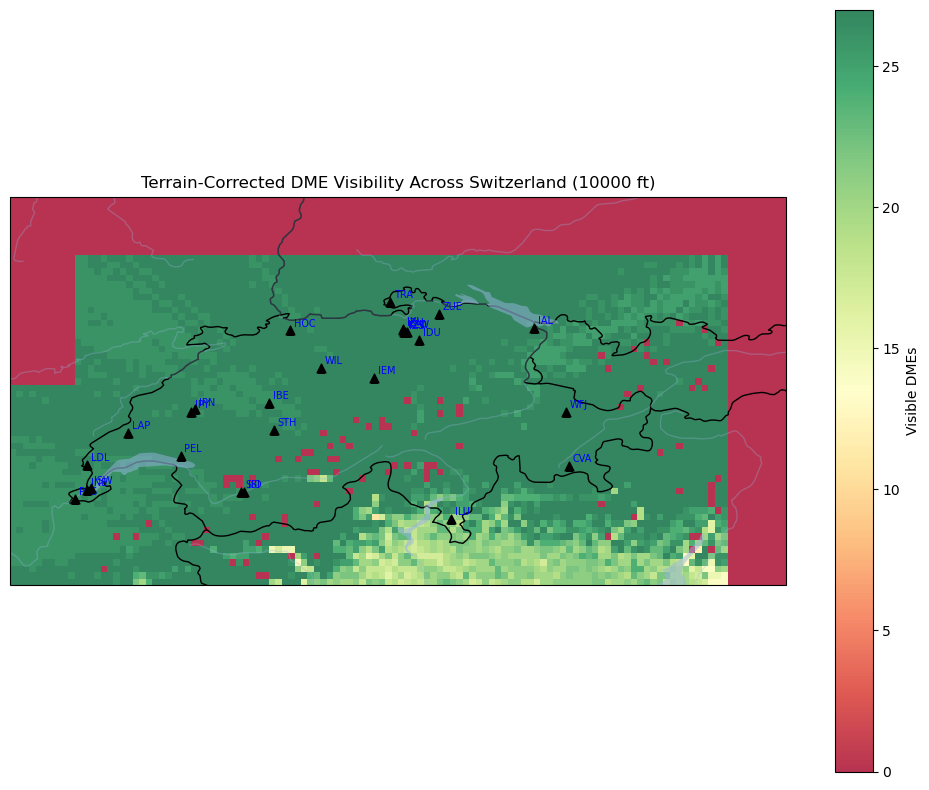

In [ ]:
fig, ax = plt.subplots(figsize=(10,8), subplot_kw={"projection": ccrs.PlateCarree()})
cmap = plt.cm.RdYlGn.copy(); cmap.set_bad("lightgrey")
im = ax.imshow(vis_matrix, extent=[lon_min, lon_max, lat_min, lat_max],
               origin="lower", cmap=cmap, alpha=0.8, transform=ccrs.PlateCarree())
ax.add_feature(cfeature.BORDERS, linewidth=1)
ax.add_feature(cfeature.LAKES, alpha=0.5)
ax.add_feature(cfeature.RIVERS, alpha=0.3)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.scatter(dfz["lon_dd"], dfz["lat_dd"], c="k", marker="^", s=40,transform=ccrs.PlateCarree(), zorder=5)
for _, r in dfz.iterrows():
    ax.text(r["lon_dd"]+0.03, r["lat_dd"]+0.03, r["Identification"],fontsize=7, color="blue", transform=ccrs.PlateCarree())
ax.set_extent([lon_min, lon_max, lat_min, lat_max])
plt.colorbar(im, ax=ax, label="Visible DMEs")
plt.title(f"Terrain-Corrected DME Visibility Across Switzerland ({altitude:.0f} ft)")
plt.tight_layout()
plt.savefig(f"DME_visibility_{altitude:.0f}ft.pdf", dpi=300, bbox_inches="tight")